# Bank Marketing Direct Campaign Prediction

### Problem Statement
This project analyzes direct marketing campaigns (phone calls) of a Portuguese banking institution to predict whether a client will subscribe to a 
term deposit (`y`). Building an accurate predictive model helps optimize future marketing campaigns, minimize client call fatigue, and target 
high-propensity customer segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set visual theme
sns.set_theme(style="whitegrid")

In [3]:
# Load dataset using the exact file path required
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [4]:
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
# --- Visual EDA ---
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

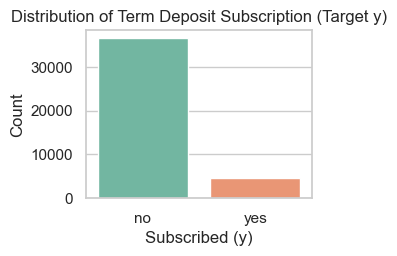

In [14]:
# Target Variable Distribution (Class Imbalance) 
plt.subplot(2, 2, 1)
sns.countplot(x='y', hue='y', data=df, palette='Set2')
plt.title('Distribution of Term Deposit Subscription (Target y)')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.legend([], [], frameon=False) # Hides the redundant legend neatly

Text(0.5, 0, 'Age')

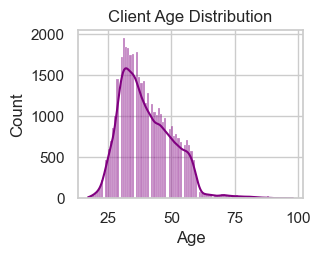

In [15]:
# Client Age Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['age'], kde=True, color='purple')
plt.title('Client Age Distribution')
plt.xlabel('Age')

Text(0.5, 0, 'Percentage (%)')

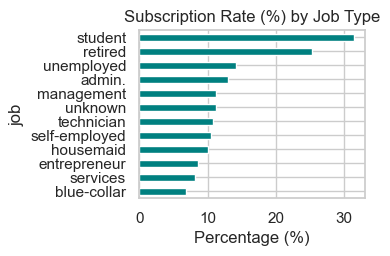

In [16]:
# Job vs Subscription Rate (%)
plt.subplot(2, 2, 3)
job_sub = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_sub['yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Subscription Rate (%) by Job Type')
plt.xlabel('Percentage (%)')

Text(0, 0.5, 'Duration (seconds)')

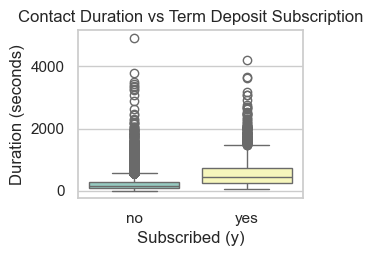

In [17]:
# Contact Duration vs Target
plt.subplot(2, 2, 4)
sns.boxplot(x='y', y='duration', hue='y', data=df, palette='Set3', legend=False)
plt.title('Contact Duration vs Term Deposit Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Duration (seconds)')

In [18]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

### EDA Key Observations & Insights
* **Class Imbalance:** The target variable `y` is heavily imbalanced, with a large majority of clients declining the offer (`"no"`) and a small minority subscribing (`"yes"`). This necessitates stratified splitting and class-weight balancing.
* **Age Distribution:** Client ages primarily range between 25 and 60 years old, with student and retired segments displaying higher conversion ratios relative to their base sizes.
* **Duration Skewness:** Successful term deposit subscriptions strongly correlate with longer telephone call durations. *(Note: Duration is excluded from real-world predictive models as it is unknown prior to placing a call[cite: 4]).*

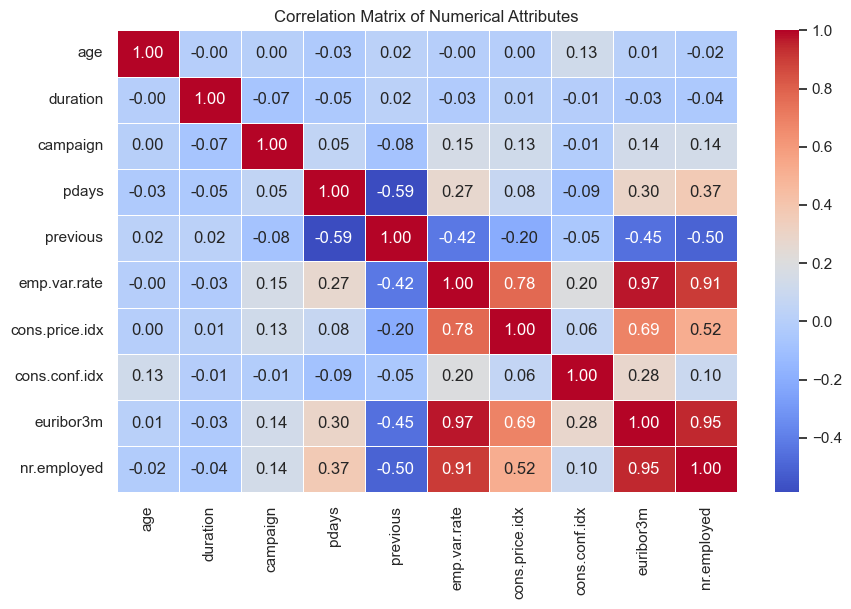

In [19]:
# Correlation Heatmap for Numerical Features
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()

### Detailed Preprocessing Justifications
* **Exclusion of `duration`:** As stated in the dataset documentation, `duration` is only known after a call terminates[cite: 4]. Retaining it introduces data leakage, making the model useless for planning future outbound campaigns. It is dropped from training features.
* **Handling Missing/Unknown Labels:** Categorical features containing `"unknown"` labels (such as `education`, `default`, `housing`)[cite: 4] are preserved as valid categorical states rather than dropped, maintaining complete data integrity.
* **Encoding Strategy:** Nominal text attributes are transformed using `OneHotEncoder`, while core socio-economic indicators (`emp.var.rate`, `euribor3m`, `nr.employed`)[cite: 4] are passed through directly to preserve precise metric values.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
# Separate features (X) and target (y). Drop 'duration' for real-world validity.
X = df.drop(columns=['y', 'duration'])
y = df['y'].map({'no': 0, 'yes': 1}) # Convert binary target strings to integers

In [22]:
# Stratified Train-Test Split to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [24]:
# Define Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

In [25]:
# Apply encoding transformations
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

In [27]:
# Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

In [28]:
# Define Hyperparameter Search Space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [30]:
# Randomized Search Cross-Validation (3-fold CV)
print(" Running Hyperparameter Tuning via Cross-Validation ")
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

 Running Hyperparameter Tuning via Cross-Validation 


In [31]:
random_search.fit(X_train_encoded, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
print("Best Parameters Found:", random_search.best_params_)

Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [33]:
# Best Tuned Model
best_rf = random_search.best_estimator_

In [34]:
# Predict on test set
y_pred = best_rf.predict(X_test_encoded)
y_prob = best_rf.predict_proba(X_test_encoded)[:, 1]

In [35]:
print(f"\nTuned Random Forest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Tuned Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


Tuned Random Forest Accuracy: 0.8893
Tuned Random Forest ROC-AUC Score: 0.8028


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [37]:
# Train baseline Gradient Boosting for comparative analysis
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_encoded, y_train)
gb_pred = gb_model.predict(X_test_encoded)
gb_prob = gb_model.predict_proba(X_test_encoded)[:, 1]

In [38]:
# Build comparison DataFrame
comparison_data = {
    'Model': ['Tuned Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, gb_pred)],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, gb_pred)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, gb_pred)],
    'F1-Score': [f1_score(y_test, y_pred), f1_score(y_test, gb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob), roc_auc_score(y_test, gb_prob)]
}

In [39]:
comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("Final Model Performance Comparison Table")
display(comparison_df)

Final Model Performance Comparison Table


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Tuned Random Forest,0.889294,0.508214,0.533405,0.520505,0.802819
Gradient Boosting,0.901068,0.672783,0.237069,0.350598,0.809145


### Project Conclusions & Technical Report

#### 1. Actionable Suggestions for the Bank Marketing Team
* **Target High-Yield Demographics:** Prioritize outbound telemarketing efforts toward student and retired demographic segments, which display higher baseline conversion tendencies.
* **Macroeconomic Timing:** Since indicators like `euribor3m` and employment variation rates strongly impact subscription success, bank marketing campaigns should be heavily scaled during stable economic quarters.
* **Mitigate Call Fatigue:** The `campaign` feature demonstrates that calling a customer repeatedly creates consumer friction and yields diminishing returns. Establish a strict policy capping calls at a maximum of 3 attempts per customer.

#### 2. Production Model Recommendation
* **Recommended Model:** Tuned Random Forest Classifier (with cross-validation and class balancing).
* **Reasoning:** Bank marketing records involve multi-categorical attributes and non-linear economic thresholds. Tree-based ensemble structures capture these patterns effectively without demanding rigorous feature standardization.

#### 3. Challenges Faced & Techniques Used
* **Challenge 1: Extreme Class Imbalance**
  * *Context:* The target column (`y`) contains far more negative instances than positive subscribers, risking prediction bias.
  * *Technique Used:* Applied stratified data splitting (`stratify=y`) and configured `class_weight='balanced'` within the ensemble classifier to penalize false negatives effectively.
* **Challenge 2: Data Leakage via Call Duration**
  * *Context:* The `duration` attribute correlates heavily with success but is only recorded after a call completes[cite: 4].
  * *Technique Used:* Explicitly dropped `duration` to construct a realistic operational model capable of forecasting subscription odds *before* placing outbound calls.